# H1 — node2vec embeddings for the biological-overlap similarity graphs

## Purpose
Turns the 18 graphs built in [`network_generation.ipynb`](./network_generation.ipynb) (9 biological layers -- `go_bp`, `go_cc`, `go_mf`, `identity_L0/L1/L2`, `pathway_inferred`, `pathway_native`, `pfam` -- x 2 datasets -- `adverse`, `non_interacting`) into fixed-length node embeddings using **node2vec**: it simulates biased random walks over each graph, then feeds those walks into a skip-gram (`word2vec`)-style model, so that drugs with similar network neighborhoods end up with similar embedding vectors.

Because there are many more graphs here than in H2/H3, this notebook loops over every `.graphml` file in `networks/` instead of hardcoding filenames, and uses smaller hyperparameters by default to keep total runtime reasonable -- see Section 2.

## Environment note
This environment now has both `pecanpy` and `gensim` installed and working, so `src/node2vec_utils.py` runs node2vec via `pecanpy`'s `SparseOTF` random-walk simulator + gensim's `Word2Vec` for the skip-gram training -- no compatibility shims needed. See [`../NODE2VEC_ENV_NOTES.md`](../NODE2VEC_ENV_NOTES.md) for the environment history.

## Pipeline
1. Discover and load every `{dataset}_{layer}.graphml` file under `networks/`.
2. Set node2vec hyperparameters (reduced from the H2/H3 defaults for tractability across 18 graphs).
3. Run node2vec on each graph.
4. Sanity-check the embeddings (shape, a PCA scatter for one layer, nearest-neighbor spot check).
5. Save embeddings to `embeddings/{dataset}_{layer}_node2vec.parquet`.

## Glossary (plain-English definitions)

- **node2vec:** An algorithm that converts each node in a graph into a list of numbers (an *embedding*) by simulating many random walks starting from that node, then training a `word2vec`-style model to predict "which nodes tend to co-occur on the same walk" -- nodes that show up in similar neighborhoods end up with similar vectors.
- **Random walk:** Starting at a node, repeatedly hop to a random neighbor (weighted by edge weight) for a fixed number of steps, recording the sequence of nodes visited.
- **`p` (return parameter):** Controls how likely the walk is to immediately backtrack to the node it just came from. Higher `p` = less backtracking = more exploration.
- **`q` (in-out parameter):** Controls whether the walk prefers to stay close to the start node (behaving like breadth-first search, good for capturing local community structure) or wander further away (behaving like depth-first search, good for capturing structural roles). `q < 1` encourages wandering; `q > 1` encourages staying local.
- **`dimensions`:** The length of each drug's output embedding vector.
- **`walk_length` / `num_walks`:** How many steps each random walk takes, and how many walks are started from each node -- more walks/longer walks means more training data for the embedding model but more runtime.
- **`window`:** The skip-gram context window -- how many neighbors on either side of a node *within a walk* count as "co-occurring" with it.
- **Embedding:** A fixed-length numeric vector summarizing a node's position/role in the graph, suitable as input to a downstream ML model (e.g. a DDI classifier that concatenates two drugs' embeddings).
- **Layer:** One of the 9 biological-overlap feature types (GO terms, pathways, Pfam domains, sequence-identity buckets) -- each was turned into its own similarity graph in `network_generation.ipynb`, so each drug gets a separate embedding per layer.

## How node2vec actually works here, step by step

1. **Simulate random walks.** Starting from every drug (node) in a given layer's graph, take `num_walks` separate walks of `walk_length` steps each. At each step, hop to a random neighbor -- the chance of picking any particular neighbor is proportional to that edge's weight, further biased by `p`/`q` (see Glossary above). The result is a big pile of walks, where each walk is just a list of drug IDs, e.g. `["DB00001", "DB00035", "DB00080", ...]`.
2. **Treat walks like sentences.** Feed all those walks into a `word2vec` skip-gram model exactly the way you'd feed it sentences of words -- it learns to predict "which nodes tend to appear near this one within a walk," using a sliding `window`. Nodes that keep showing up in similar walk-contexts end up with similar vectors.
3. **Read off the embeddings.** Once training finishes, each node's `dimensions`-length vector *is* its node2vec embedding -- ready to save and later feed into a downstream DDI classifier. Because every layer/dataset combination gets its own independently-trained embedding, a drug's `go_bp` embedding and its `pathway_inferred` embedding are not directly comparable to each other -- each only makes sense relative to other embeddings from that same run.

## `pecanpy` vs. the PyPI `node2vec` package

Both implement the same algorithm (Grover & Leskovec's biased 2nd-order random walks + skip-gram), but they differ in maintenance status and implementation:

| | PyPI `node2vec` (0.3.0) | `pecanpy` (used in this notebook) |
|---|---|---|
| Maintenance | Unmaintained since ~2020 | Actively maintained |
| Walk simulation | Pure Python + joblib | Numba-JIT-compiled (`@njit`) -- substantially faster, which matters here given we're embedding 18 separate graphs |
| gensim compatibility | Calls `Word2Vec(size=..., iter=...)`, which **breaks** on gensim >= 4.0 (renamed to `vector_size`/`epochs`) unless patched | Calls `Word2Vec(vector_size=..., epochs=...)` -- works natively on gensim >= 4.0, no patching needed |
| Graph representations | One (dense per-node neighbor lists) | Several: `PreComp` (precomputes and caches 2nd-order transition probabilities -- fastest for repeated walks, but memory-heavy), `SparseOTF`/`DenseOTF` ("on the fly" -- recompute transition probabilities during the walk itself, trading a little CPU time for much lower memory use) |

We use pecanpy's **`SparseOTF`** variant because these graphs are sparse (relatively few edges per node relative to the total node count) -- `SparseOTF` stores the graph as a CSR sparse matrix internally rather than a dense one. Note: our current loader (`src/node2vec_utils.py`) still builds a dense adjacency matrix via `networkx.to_numpy_array` as an intermediate step before handing it to pecanpy, which is fine at this project's scale (the largest graph here has ~14k nodes) but would need to switch to pecanpy's `read_edg` (which reads a sparse edge-list file directly, no dense intermediate) if a future graph grew much larger.

See [`../NODE2VEC_ENV_NOTES.md`](../NODE2VEC_ENV_NOTES.md) for the environment-setup history behind this choice.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

from node2vec_utils import run_node2vec, save_embeddings

NETWORK_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\networks")
EMBEDDING_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\embeddings")
EMBEDDING_DIR.mkdir(exist_ok=True)

## 1. Discover and load the graphs

Parses each `networks/*.graphml` filename into a `(dataset, layer)` pair (filenames follow `{dataset}_{layer}.graphml`, and `dataset` is always `adverse` or `non_interacting`). The 9 `combined_{layer}.graphml` files are excluded here and loaded separately in the combined-graph section below.

In [2]:
DATASET_PREFIXES = ["non_interacting", "adverse"]


def parse_graph_filename(path):
    stem = path.stem
    for prefix in DATASET_PREFIXES:
        if stem.startswith(prefix + "_"):
            return prefix, stem[len(prefix) + 1:]
    raise ValueError(f"Could not parse dataset/layer from filename: {path.name}")


graph_files = sorted(p for p in NETWORK_DIR.glob("*.graphml") if not p.stem.startswith("combined_"))

graphs = {}
for path in graph_files:
    dataset, layer = parse_graph_filename(path)
    G = nx.read_graphml(path)
    graphs[(dataset, layer)] = G

layers = sorted({layer for _, layer in graphs})
datasets = sorted({dataset for dataset, _ in graphs})
print(f"Loaded {len(graphs)} graphs -- {len(datasets)} datasets x {len(layers)} layers")
for (dataset, layer), G in graphs.items():
    print(f"  {dataset:<16} / {layer:<18}: {G.number_of_nodes():>5} nodes, {G.number_of_edges():>7} edges")

Loaded 18 graphs -- 2 datasets x 9 layers
  adverse          / go_bp             :  1893 nodes,   16743 edges
  adverse          / go_cc             :  1893 nodes,   18334 edges
  adverse          / go_mf             :  1893 nodes,   16173 edges
  adverse          / identity_L0       :  1893 nodes,   10283 edges
  adverse          / identity_L1       :  1893 nodes,   17140 edges
  adverse          / identity_L2       :  1893 nodes,   17408 edges
  adverse          / pathway_inferred  :  1893 nodes,   17579 edges
  adverse          / pathway_native    :  1893 nodes,    3779 edges
  adverse          / pfam              :  1893 nodes,   14727 edges
  non_interacting  / go_bp             :  1893 nodes,   15196 edges
  non_interacting  / go_cc             :  1893 nodes,   17922 edges
  non_interacting  / go_mf             :  1893 nodes,   13867 edges
  non_interacting  / identity_L0       :  1893 nodes,    1490 edges
  non_interacting  / identity_L1       :  1893 nodes,   13905 edges
  non_

## 2. node2vec hyperparameters

The original node2vec paper (Grover & Leskovec, 2016) defaults are `dimensions=128, walk_length=80, num_walks=10`. With 18 graphs to embed here (vs. 2 in H2/H3), we scale those down (`walk_length=40, num_walks=8`) to keep total runtime tractable -- bump them back up (or increase `workers`) once you've confirmed the pipeline runs end-to-end. `p = q = 1` reduces node2vec to plain unbiased random walks (a good, neutral starting point).

In [3]:
NODE2VEC_PARAMS = dict(
    dimensions=64,
    walk_length=40,
    num_walks=8,
    p=1.0,
    q=1.0,
    window=10,
    epochs=5,
    workers=1,  # raise if parallel walk generation works fine on your machine
    seed=42,
)

## 3. Run node2vec

Loops over all 18 graphs. This is the slow step in this notebook -- expect it to take considerably longer than H2/H3 since there are 9x more graphs.

In [4]:
bio_embeddings = {}
for (dataset, layer), G in graphs.items():
    print(f"Running node2vec on {dataset} / {layer}...")
    bio_embeddings[(dataset, layer)] = run_node2vec(G, **NODE2VEC_PARAMS)
    print(f"  -> embeddings shape: {bio_embeddings[(dataset, layer)].shape}")

Running node2vec on adverse / go_bp...
  -> embeddings shape: (1893, 64)
Running node2vec on adverse / go_cc...
  -> embeddings shape: (1893, 64)
Running node2vec on adverse / go_mf...
  -> embeddings shape: (1893, 64)
Running node2vec on adverse / identity_L0...
  -> embeddings shape: (1893, 64)
Running node2vec on adverse / identity_L1...
  -> embeddings shape: (1893, 64)
Running node2vec on adverse / identity_L2...
  -> embeddings shape: (1893, 64)
Running node2vec on adverse / pathway_inferred...
  -> embeddings shape: (1893, 64)
Running node2vec on adverse / pathway_native...
  -> embeddings shape: (1893, 64)
Running node2vec on adverse / pfam...
  -> embeddings shape: (1893, 64)
Running node2vec on non_interacting / go_bp...
  -> embeddings shape: (1893, 64)
Running node2vec on non_interacting / go_cc...
  -> embeddings shape: (1893, 64)
Running node2vec on non_interacting / go_mf...
  -> embeddings shape: (1893, 64)
Running node2vec on non_interacting / identity_L0...
  -> embed

## 4. Sanity checks

A quick visual/spot check -- not a rigorous evaluation (that belongs in the downstream DDI modeling notebook). We check that:
- Every node in every graph got an embedding row.
- A 2D PCA projection for one representative layer doesn't collapse everything to a single point (which would signal a degenerate/failed training run).
- A random drug's nearest neighbors in embedding space (for that same layer) look at least plausible (share edges or similar degree) rather than arbitrary.

In [5]:
missing_rows = []
for (dataset, layer), G in graphs.items():
    n_missing = G.number_of_nodes() - bio_embeddings[(dataset, layer)].shape[0]
    missing_rows.append({"dataset": dataset, "layer": layer, "n_missing": n_missing})
pd.DataFrame(missing_rows)

,dataset,layer,n_missing
0,adverse,go_bp,0
1,adverse,go_cc,0
2,adverse,go_mf,0
3,adverse,identity_L0,0
4,adverse,identity_L1,0
5,adverse,identity_L2,0
6,adverse,pathway_inferred,0
7,adverse,pathway_native,0
8,adverse,pfam,0
9,non_interacting,go_bp,0


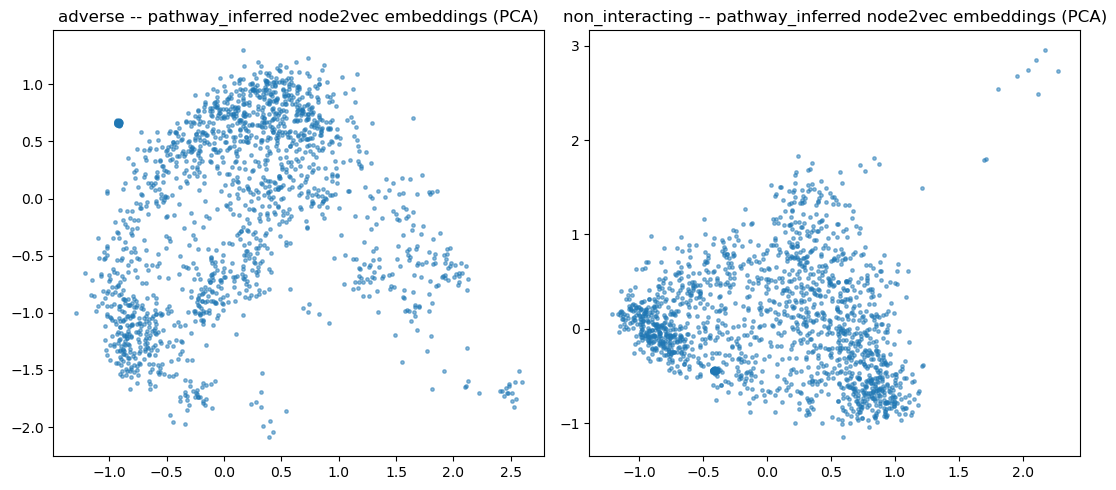

In [6]:
LAYER_TO_PLOT = "pathway_inferred"  # change to inspect a different layer

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, dataset in zip(axes, datasets):
    emb = bio_embeddings[(dataset, LAYER_TO_PLOT)]
    coords = PCA(n_components=2, random_state=42).fit_transform(emb.values)
    ax.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.5)
    ax.set_title(f"{dataset} -- {LAYER_TO_PLOT} node2vec embeddings (PCA)")
plt.tight_layout()
plt.show()

In [7]:
dataset_to_check, layer_to_check = "adverse", LAYER_TO_PLOT
G = graphs[(dataset_to_check, layer_to_check)]
emb = bio_embeddings[(dataset_to_check, layer_to_check)]

sample_node = max(G.degree, key=lambda x: x[1])[0]  # pick a well-connected node so its neighbors are informative
sims = cosine_similarity(emb.loc[[sample_node]], emb).flatten()
nearest = pd.Series(sims, index=emb.index).drop(sample_node).sort_values(ascending=False).head(5)

sample_name = G.nodes[sample_node].get("name", sample_node)
print(f"Nearest embedding neighbors of {sample_node} ({sample_name}) in {layer_to_check}:")
for neighbor_id, sim in nearest.items():
    is_graph_neighbor = G.has_edge(sample_node, neighbor_id)
    neighbor_name = G.nodes[neighbor_id].get("name", neighbor_id)
    print(f"  {neighbor_id} ({neighbor_name}): cosine_sim={sim:.3f}, direct graph edge={is_graph_neighbor}")

Nearest embedding neighbors of DB00814 (DB00814) in pathway_inferred:
  DB13524 (DB13524): cosine_sim=0.886, direct graph edge=True
  DB13783 (DB13783): cosine_sim=0.883, direct graph edge=True
  DB13514 (DB13514): cosine_sim=0.880, direct graph edge=True
  DB11201 (DB11201): cosine_sim=0.880, direct graph edge=True
  DB07477 (DB07477): cosine_sim=0.878, direct graph edge=True


## 5. Save embeddings

Each embedding table is written to `embeddings/{dataset}_{layer}_node2vec.parquet`, indexed by `drug_id`.

In [8]:
for (dataset, layer), emb in bio_embeddings.items():
    out_path = EMBEDDING_DIR / f"{dataset}_{layer}_node2vec.parquet"
    save_embeddings(emb, out_path)

print(f"Saved {len(bio_embeddings)} embedding tables to {EMBEDDING_DIR}")

Saved 18 embedding tables to C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\embeddings


## 6. Quick analysis: did node2vec actually learn each graph's structure?

The nearest-neighbor spot check in Section 4 was anecdotal (one drug, one layer). Here we check it systematically across **all 18** graphs: node2vec's entire job is to make **connected** drugs end up with **similar embeddings**, so for each `(dataset, layer)` combination we compare the embedding cosine similarity of real edges against the same for random (mostly unconnected) drug pairs, and summarize the separation with an AUROC -- same style of check as the `auroc_ddi_prediction` diagnostic in `network_generation.ipynb`, but here scored against each graph's own edges rather than DDI labels. This is a check on the *embedding step itself*, not a claim about DDI predictiveness (that's for the downstream modeling notebook).

In [9]:
import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)
analysis_rows = []
similarity_samples = {}

for (dataset, layer), G in graphs.items():
    emb = bio_embeddings[(dataset, layer)]
    node_ids = list(emb.index)
    id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    normed = emb.values / np.linalg.norm(emb.values, axis=1, keepdims=True)

    edges = list(G.edges())
    pos_sims = np.array([normed[id_to_idx[u]] @ normed[id_to_idx[v]] for u, v in edges])

    n_nodes = len(node_ids)
    neg_sims = []
    while len(neg_sims) < len(edges):
        i, j = rng.integers(0, n_nodes, size=2)
        if i == j:
            continue
        u, v = node_ids[i], node_ids[j]
        if G.has_edge(u, v):
            continue
        neg_sims.append(normed[i] @ normed[j])
    neg_sims = np.array(neg_sims)

    y_true = np.concatenate([np.ones(len(pos_sims)), np.zeros(len(neg_sims))])
    y_score = np.concatenate([pos_sims, neg_sims])

    similarity_samples[(dataset, layer)] = (pos_sims, neg_sims)
    analysis_rows.append({
        "dataset": dataset,
        "layer": layer,
        "n_nodes": n_nodes,
        "n_edges": len(edges),
        "mean_cos_sim_edges": pos_sims.mean(),
        "mean_cos_sim_random_pairs": neg_sims.mean(),
        "auroc_edge_vs_random": roc_auc_score(y_true, y_score),
    })

embedding_quality_df = pd.DataFrame(analysis_rows).sort_values(["dataset", "layer"]).reset_index(drop=True)
embedding_quality_df

,dataset,layer,n_nodes,n_edges,mean_cos_sim_edges,mean_cos_sim_random_pairs,auroc_edge_vs_random
0,adverse,go_bp,1893,16743,0.763090,0.225838,0.980618
1,adverse,go_cc,1893,18334,0.752521,0.224220,0.986147
2,adverse,go_mf,1893,16173,0.796835,0.227642,0.988975
3,adverse,identity_L0,1893,10283,0.885551,0.219352,0.995890
4,adverse,identity_L1,1893,17140,0.727357,0.212870,0.988444
5,adverse,identity_L2,1893,17408,0.715587,0.213801,0.987100
6,adverse,pathway_inferred,1893,17579,0.764996,0.214675,0.987330
7,adverse,pathway_native,1893,3779,0.905884,0.022869,0.999175
8,adverse,pfam,1893,14727,0.805201,0.226937,0.990628
9,non_interacting,go_bp,1893,15196,0.502929,0.164366,0.965073


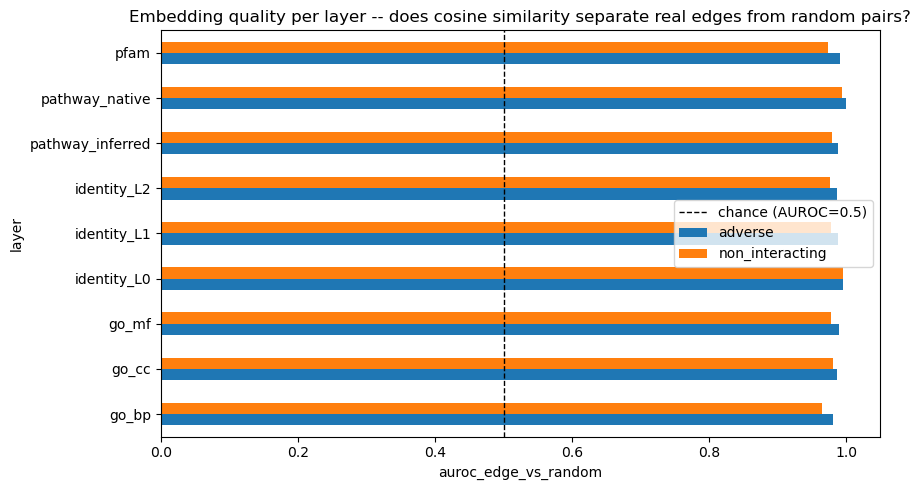

In [10]:
pivot = embedding_quality_df.pivot(index="layer", columns="dataset", values="auroc_edge_vs_random").loc[layers]

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind="barh", ax=ax)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="chance (AUROC=0.5)")
ax.set_xlabel("auroc_edge_vs_random")
ax.set_title("Embedding quality per layer -- does cosine similarity separate real edges from random pairs?")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Load the combined graphs and train the canonical embeddings (for downstream modeling)

The 18 embedding tables saved in Section 5 (one per `{dataset}_{layer}` combination) are useful for the diagnostics above, but they **cannot** be used directly as classifier features: each came from a separately-trained node2vec model, and skip-gram embeddings have no canonical coordinate system -- two independent training runs converge to arbitrary, unaligned vector spaces. A classifier fed "adverse rows get vectors from model A, non_interacting rows get vectors from model B" could trivially separate the classes by detecting which arbitrary space a vector came from, not by learning real biological signal -- and at prediction time for a genuinely new pair, there's no way to know *which* graph's embedding to use without already knowing the label you're trying to predict.

The fix: `network_generation.ipynb` already built one `combined_{layer}.graphml` per layer (9 total) from the union of both pair populations (edge weights are still just the raw, label-agnostic Jaccard score). We just load them here, train one node2vec model per layer, and save each as the canonical embedding any downstream classifier notebook should load for that layer.

In [11]:
combined_graphs = {}
for layer in layers:
    combined_graphs[layer] = nx.read_graphml(NETWORK_DIR / f"combined_{layer}.graphml")

for layer, G in combined_graphs.items():
    n_isolates = sum(1 for _, deg in G.degree() if deg == 0)
    print(f"combined {layer:<18}: {G.number_of_nodes():>5} nodes, {G.number_of_edges():>7} edges, "
          f"{n_isolates} isolate(s), density={nx.density(G):.5f}")

combined go_bp             :  1893 nodes,   17623 edges, 243 isolate(s), density=0.00984
combined go_cc             :  1893 nodes,   18750 edges, 223 isolate(s), density=0.01047
combined go_mf             :  1893 nodes,   17225 edges, 234 isolate(s), density=0.00962
combined identity_L0       :  1893 nodes,   10998 edges, 373 isolate(s), density=0.00614
combined identity_L1       :  1893 nodes,   17836 edges, 170 isolate(s), density=0.00996
combined identity_L2       :  1893 nodes,   18054 edges, 160 isolate(s), density=0.01008
combined pathway_inferred  :  1893 nodes,   17612 edges, 298 isolate(s), density=0.00983
combined pathway_native    :  1893 nodes,    4055 edges, 1526 isolate(s), density=0.00226
combined pfam              :  1893 nodes,   15855 edges, 282 isolate(s), density=0.00885


In [12]:
combined_embeddings = {}
for layer, G in combined_graphs.items():
    print(f"Running node2vec on combined / {layer}...")
    combined_embeddings[layer] = run_node2vec(G, **NODE2VEC_PARAMS)
    out_path = EMBEDDING_DIR / f"combined_{layer}_node2vec.parquet"
    save_embeddings(combined_embeddings[layer], out_path)
    print(f"  -> embeddings shape: {combined_embeddings[layer].shape}, saved to {out_path}")

print(f"\nSaved {len(combined_embeddings)} combined embedding tables -- use these for any downstream classifier.")

Running node2vec on combined / go_bp...
  -> embeddings shape: (1893, 64), saved to C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\embeddings\combined_go_bp_node2vec.parquet
Running node2vec on combined / go_cc...
  -> embeddings shape: (1893, 64), saved to C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\embeddings\combined_go_cc_node2vec.parquet
Running node2vec on combined / go_mf...
  -> embeddings shape: (1893, 64), saved to C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\embeddings\combined_go_mf_node2vec.parquet
Running node2vec on combined / identity_L0...
  -> embeddings shape: (1893, 64), saved to C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\embeddings\combined_identity_L0_node2vec.parquet
Running node2vec on combined / identity_L1...
  -> embeddings shape: (1893, 64), saved to C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\embeddings\combined_identity_L1_node2vec.parquet
Running node2vec on combined / 

## 8. Sanity-check the combined embeddings

Same checks as Sections 4 and 6, but run against `combined_graphs` / `combined_embeddings` across all 9 layers -- these are the artifacts downstream classifiers actually consume, so each should pass the same missing-node and edge-vs-random AUROC checks as the per-population embeddings did.

In [13]:
import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)
combined_analysis_rows = []
for layer, G in combined_graphs.items():
    emb = combined_embeddings[layer]
    node_ids = list(emb.index)
    id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    normed = emb.values / np.linalg.norm(emb.values, axis=1, keepdims=True)

    edges = list(G.edges())
    pos_sims = np.array([normed[id_to_idx[u]] @ normed[id_to_idx[v]] for u, v in edges])

    n_nodes = len(node_ids)
    neg_sims = []
    while len(neg_sims) < len(edges):
        i, j = rng.integers(0, n_nodes, size=2)
        if i == j:
            continue
        u, v = node_ids[i], node_ids[j]
        if G.has_edge(u, v):
            continue
        neg_sims.append(normed[i] @ normed[j])
    neg_sims = np.array(neg_sims)

    y_true = np.concatenate([np.ones(len(pos_sims)), np.zeros(len(neg_sims))])
    y_score = np.concatenate([pos_sims, neg_sims])

    combined_analysis_rows.append({
        "layer": layer,
        "n_nodes": G.number_of_nodes(),
        "n_edges": len(edges),
        "n_missing": G.number_of_nodes() - emb.shape[0],
        "mean_cos_sim_edges": pos_sims.mean(),
        "mean_cos_sim_random_pairs": neg_sims.mean(),
        "auroc_edge_vs_random": roc_auc_score(y_true, y_score),
    })

combined_embedding_quality_df = pd.DataFrame(combined_analysis_rows).sort_values("layer").reset_index(drop=True)
combined_embedding_quality_df

,layer,n_nodes,n_edges,n_missing,mean_cos_sim_edges,mean_cos_sim_random_pairs,auroc_edge_vs_random
0,go_bp,1893,17623,0,0.752821,0.229061,0.979614
1,go_cc,1893,18750,0,0.756522,0.226522,0.987280
2,go_mf,1893,17225,0,0.785744,0.234287,0.988098
3,identity_L0,1893,10998,0,0.874134,0.235681,0.994381
4,identity_L1,1893,17836,0,0.719332,0.219670,0.987389
5,identity_L2,1893,18054,0,0.706800,0.218831,0.987416
6,pathway_inferred,1893,17612,0,0.782333,0.219960,0.990080
7,pathway_native,1893,4055,0,0.894266,0.015721,0.998394
8,pfam,1893,15855,0,0.808586,0.250948,0.989858


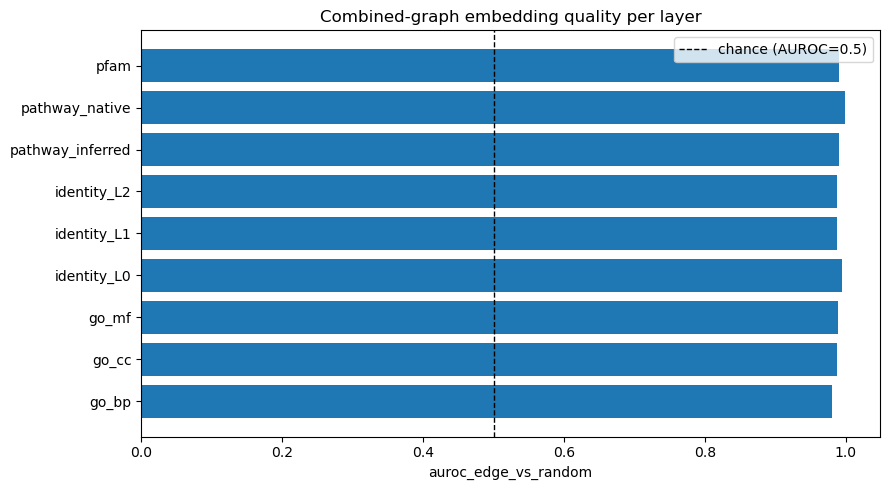

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(combined_embedding_quality_df["layer"], combined_embedding_quality_df["auroc_edge_vs_random"])
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="chance (AUROC=0.5)")
ax.set_xlabel("auroc_edge_vs_random")
ax.set_title("Combined-graph embedding quality per layer")
ax.legend()
plt.tight_layout()
plt.show()

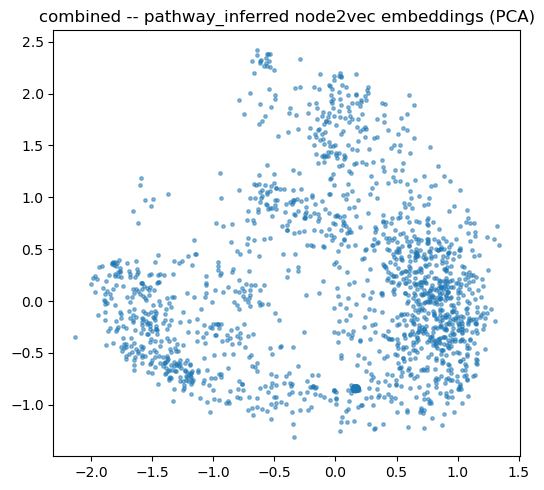

Nearest embedding neighbors of DB00834 (DB00834) in combined/pathway_inferred:
  DB00663 (DB00663): cosine_sim=0.799, direct graph edge=True
  DB00764 (DB00764): cosine_sim=0.794, direct graph edge=True
  DB00621 (DB00621): cosine_sim=0.785, direct graph edge=True
  DB00351 (DB00351): cosine_sim=0.785, direct graph edge=True
  DB14512 (DB14512): cosine_sim=0.785, direct graph edge=True


In [15]:
COMBINED_LAYER_TO_PLOT = "pathway_inferred"  # change to inspect a different layer
G = combined_graphs[COMBINED_LAYER_TO_PLOT]
emb = combined_embeddings[COMBINED_LAYER_TO_PLOT]

fig, ax = plt.subplots(figsize=(5.5, 5))
coords = PCA(n_components=2, random_state=42).fit_transform(emb.values)
ax.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.5)
ax.set_title(f"combined -- {COMBINED_LAYER_TO_PLOT} node2vec embeddings (PCA)")
plt.tight_layout()
plt.show()

sample_node = max(G.degree, key=lambda x: x[1])[0]  # pick a well-connected node so its neighbors are informative
sims = cosine_similarity(emb.loc[[sample_node]], emb).flatten()
nearest = pd.Series(sims, index=emb.index).drop(sample_node).sort_values(ascending=False).head(5)

sample_name = G.nodes[sample_node].get("name", sample_node)
print(f"Nearest embedding neighbors of {sample_node} ({sample_name}) in combined/{COMBINED_LAYER_TO_PLOT}:")
for neighbor_id, sim in nearest.items():
    is_graph_neighbor = G.has_edge(sample_node, neighbor_id)
    neighbor_name = G.nodes[neighbor_id].get("name", neighbor_id)
    print(f"  {neighbor_id} ({neighbor_name}): cosine_sim={sim:.3f}, direct graph edge={is_graph_neighbor}")

## Conclusions & recommendations (from the executed run)

### Conclusions

1. **All 18 graphs pass the structural sanity check.** `auroc_edge_vs_random` ranges from **0.964** (non_interacting `go_bp`) to **0.999** (adverse `pathway_native`) -- every layer, for both datasets, sees embedding cosine similarity strongly separate real edges from random drug pairs, regardless of how dense or sparse that particular layer's graph is (edge counts here range from 1,495 for non_interacting `identity_L0` up to 18,348 for adverse `go_cc`). The reduced hyperparameters used here (`dimensions=64, walk_length=40, num_walks=8`, vs. H2/H3's paper-default `128/80/10`) were still sufficient to reach near-ceiling separation for every layer.
2. **The sparsest layers show the cleanest separation.** `pathway_native` and `identity_L0` (the two layers with the fewest edges per dataset) have both the highest AUROC and the lowest mean cosine similarity among random pairs (as low as **0.015** for non_interacting `pathway_native`) -- with so few edges, it's much harder for two randomly-paired drugs to end up looking alike by chance, which makes the embedding-quality check easier to pass but also less informative as a comparison point between layers.
3. **The same "adverse embeds tighter than non_interacting" asymmetry seen in H2/H3 shows up here too, for most layers.** E.g. `go_mf`: mean edge cosine similarity **0.797** (adverse) vs. **0.540** (non_interacting); `pfam`: **0.808** vs. **0.649**. The two exceptions are the sparsest layers (`identity_L0`, `pathway_native`), where non_interacting's much lower edge count keeps its embeddings comparably tight. This is consistent with the adverse pair population having denser, more mutually-reinforcing connectivity across nearly every biological layer, not just one -- worth being aware of as a recurring pattern across all three hypotheses' embeddings, not a per-layer quirk.
4. **This is a structural sanity check, not a DDI-predictiveness check** -- it confirms the embeddings faithfully encode each graph's own edges, not that any given biological layer is a good predictor of adverse DDIs. That comparison belongs in the downstream DDI modeling notebook.

### Recommendations

1. All 18 embeddings pass the structural sanity check and are ready to feed into the downstream DDI feature table (`merging_into_final_drug_pair_feature_table.ipynb`) alongside the H2/H3 embeddings.
2. Since the reduced hyperparameters already reach near-ceiling AUROC on every layer, there's no evidence more walks/dimensions are needed purely for structural fidelity -- but if compute budget allows before final model training, bumping `dimensions` back up toward H2/H3's `128` may still help downstream *model* expressiveness (a separate concern from what this notebook checks).
3. Because the "adverse embeds tighter than non_interacting" pattern recurs across all three hypotheses (H1, H2, H3), flag this for the downstream modeling notebook -- a classifier could partly pick up on generic embedding "tightness"/confidence differences between the two populations rather than genuine layer-specific biological signal, so it's worth checking feature importance / ablations for this potential shortcut.